# KNN on Dummy  Data

This notebook uses a small dummy banking dataset with only three fields:
- `credit_score`
- `income`
- `status`

The goal is to predict customer status using the K-Nearest Neighbors (KNN) algorithm.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

sns.set_style("whitegrid")

In [7]:
data = {
    "credit_score": [720, 680, 650, 600, 580, 750, 800, 620, 590, 710, 690, 640, 610, 770, 730, 560, 540, 660, 700, 780],
    "income": [85000, 72000, 60000, 45000, 40000, 92000, 110000, 50000, 38000, 80000, 75000, 58000, 47000, 98000, 87000, 35000, 30000, 62000, 78000, 105000],
    "status": ["Approved", "Approved", "Approved", "Rejected", "Rejected", "Approved", "Approved", "Rejected", "Rejected", "Approved", "Approved", "Rejected", "Rejected", "Approved", "Approved", "Rejected", "Rejected", "Approved", "Approved", "Approved"]
}

df = pd.DataFrame(data)
df.shape

(20, 3)

In [8]:
df["status"].value_counts()

status
Approved    12
Rejected     8
Name: count, dtype: int64

## Visualization

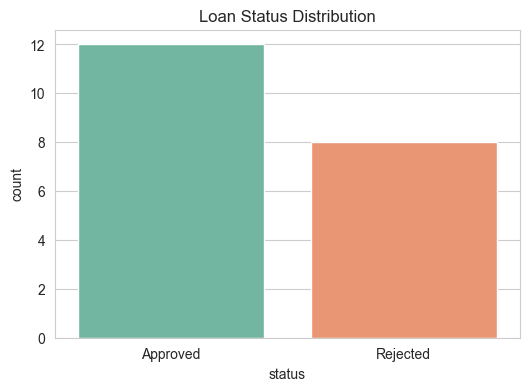

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="status", hue="status", palette="Set2", legend=False)
plt.title("Loan Status Distribution")
plt.show()

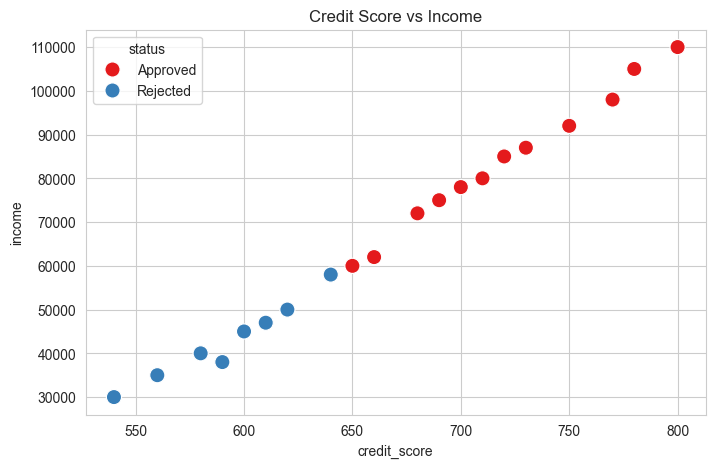

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="credit_score", y="income", hue="status", s=120, palette="Set1")
plt.title("Credit Score vs Income")
plt.show()

## Train KNN Model

In [11]:
# 
X =df[['credit_score','income']]
Y = df['status']

In [12]:
X,Y

(    credit_score  income
 0            720   85000
 1            680   72000
 2            650   60000
 3            600   45000
 4            580   40000
 5            750   92000
 6            800  110000
 7            620   50000
 8            590   38000
 9            710   80000
 10           690   75000
 11           640   58000
 12           610   47000
 13           770   98000
 14           730   87000
 15           560   35000
 16           540   30000
 17           660   62000
 18           700   78000
 19           780  105000,
 0     Approved
 1     Approved
 2     Approved
 3     Rejected
 4     Rejected
 5     Approved
 6     Approved
 7     Rejected
 8     Rejected
 9     Approved
 10    Approved
 11    Rejected
 12    Rejected
 13    Approved
 14    Approved
 15    Rejected
 16    Rejected
 17    Approved
 18    Approved
 19    Approved
 Name: status, dtype: str)

In [13]:
model = KNeighborsClassifier(n_neighbors=3)
# 
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.20)

In [14]:
model.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [15]:
x_test

,credit_score,income
19,780,105000
12,610,47000
7,620,50000
18,700,78000


In [16]:
# predictions
y_pred = model.predict(x_test)

In [17]:
accuracy_score(y_pred,y_test)

1.0

In [1]:
import pickle
# with open('knn_model_v1.pkl','wb') as file:
#     pickle.dump(model,file)

In [2]:
with open('knn_model_v1.pkl','rb') as file:
    model = pickle.load(file)



## Sample Prediction

In [ ]:
import pandas as pd
new_customer = pd.DataFrame({
    "credit_score": [321],
    "income": [68000]
})

prediction = model.predict_proba(new_customer)



NameError: name 'pd' is not defined

In [ ]:
prediction

array([[1., 0.]])